In [44]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib

from sklearn.model_selection import train_test_split

In [45]:
#load dataset
df = pd.read_csv("../data/processed_stock_data.csv")

df.head()

,Date,Unnamed: 0,Close,High,Low,Open,Volume,Returns,MA20,MA50,...,return_lag_5,rolling_mean_10,rolling_mean_30,momentum_5,momentum_10,momentum_30,day_of_week,month,quarter,target
0,2010-03-16,49,86.877113,86.959201,86.190510,86.429327,168673000,0.007966,84.156820,83.279019,...,0.001662,85.503896,82.955024,0.017037,0.037523,0.067394,1,3,1,1
1,2010-03-17,50,87.392036,87.675635,86.884550,87.138296,177468100,0.005927,84.412056,83.335290,...,0.004456,85.862122,83.122196,0.018526,0.042743,0.060881,2,3,1,0
2,2010-03-18,51,87.347275,87.518921,86.996512,87.399516,196509100,-0.000512,84.640797,83.386189,...,0.004175,86.190495,83.301558,0.013773,0.039062,0.065647,3,3,1,0
3,2010-03-19,52,86.905121,87.894297,86.567898,86.905121,226641100,-0.005062,84.838849,83.427050,...,0.000087,86.354500,83.550513,0.008553,0.019235,0.094021,4,3,1,1
4,2010-03-22,53,87.369728,87.527102,86.358072,86.410528,184477800,0.005346,85.059385,83.470038,...,0.000260,86.563472,83.809483,0.013681,0.024504,0.097601,0,3,1,1


In [46]:
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

df.head()

,Date,Close,High,Low,Open,Volume,Returns,MA20,MA50,Volatility,...,return_lag_5,rolling_mean_10,rolling_mean_30,momentum_5,momentum_10,momentum_30,day_of_week,month,quarter,target
0,2010-03-16,86.877113,86.959201,86.190510,86.429327,168673000,0.007966,84.156820,83.279019,0.005395,...,0.001662,85.503896,82.955024,0.017037,0.037523,0.067394,1,3,1,1
1,2010-03-17,87.392036,87.675635,86.884550,87.138296,177468100,0.005927,84.412056,83.335290,0.005422,...,0.004456,85.862122,83.122196,0.018526,0.042743,0.060881,2,3,1,0
2,2010-03-18,87.347275,87.518921,86.996512,87.399516,196509100,-0.000512,84.640797,83.386189,0.005433,...,0.004175,86.190495,83.301558,0.013773,0.039062,0.065647,3,3,1,0
3,2010-03-19,86.905121,87.894297,86.567898,86.905121,226641100,-0.005062,84.838849,83.427050,0.005704,...,0.000087,86.354500,83.550513,0.008553,0.019235,0.094021,4,3,1,1
4,2010-03-22,87.369728,87.527102,86.358072,86.410528,184477800,0.005346,85.059385,83.470038,0.005718,...,0.000260,86.563472,83.809483,0.013681,0.024504,0.097601,0,3,1,1


In [47]:
#drop missing values
df = df.dropna().reset_index(drop=True)

print(df.shape)

(3725, 43)


In [48]:
#features and target
X = df.drop(columns=["target", "Date"])

y = df["target"]

print(X.shape)
print(y.shape)

(3725, 41)
(3725,)


In [49]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [50]:
#load saved model
model = joblib.load("../models/best_xgboost_5day.pkl")

print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


In [51]:
#predictions
predictions = model.predict(X_test)

results = pd.DataFrame(index=X_test.index)

results["Prediction"] = predictions
results["Actual"] = y_test

results.head()

,Prediction,Actual
2980,1,1
2981,1,0
2982,1,0
2983,1,0
2984,1,0


In [52]:
#add close prices
results["Close"] = df.loc[X_test.index, "Close"]

results.head()

,Prediction,Actual,Close
2980,1,1,437.085205
2981,1,0,437.263916
2982,1,0,429.520111
2983,1,0,425.060272
2984,1,0,420.355652


In [53]:

#trading signals
results["Signal"] = results["Prediction"]

results.head()

,Prediction,Actual,Close,Signal
2980,1,1,437.085205,1
2981,1,0,437.263916,1
2982,1,0,429.520111,1
2983,1,0,425.060272,1
2984,1,0,420.355652,1


In [54]:
#market returns
results["Market_Return"] = results["Close"].pct_change()

results.head()

,Prediction,Actual,Close,Signal,Market_Return
2980,1,1,437.085205,1,NaN
2981,1,0,437.263916,1,0.000409
2982,1,0,429.520111,1,-0.017710
2983,1,0,425.060272,1,-0.010383
2984,1,0,420.355652,1,-0.011068


In [55]:
#strategy returns
results["Strategy_Return"] = (
    results["Signal"].shift(1)
    * results["Market_Return"]
)

results.head()

,Prediction,Actual,Close,Signal,Market_Return,Strategy_Return
2980,1,1,437.085205,1,NaN,NaN
2981,1,0,437.263916,1,0.000409,0.000409
2982,1,0,429.520111,1,-0.017710,-0.017710
2983,1,0,425.060272,1,-0.010383,-0.010383
2984,1,0,420.355652,1,-0.011068,-0.011068


In [56]:
#cumulative returns
results["Market_Cumulative"] = (
    1 + results["Market_Return"]
).cumprod()

results["Strategy_Cumulative"] = (
    1 + results["Strategy_Return"]
).cumprod()

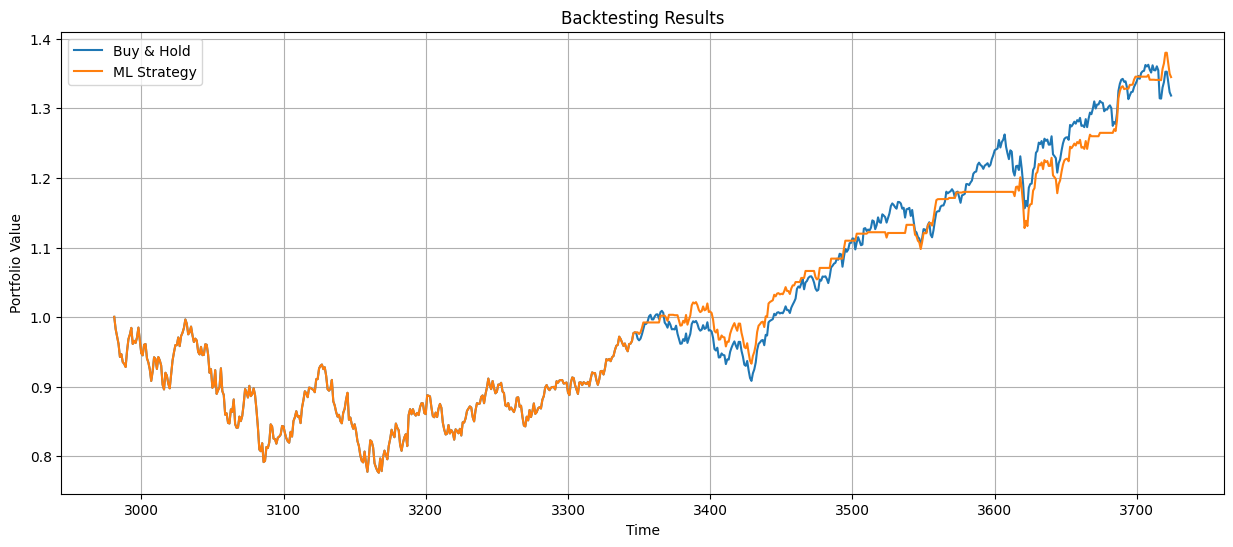

In [57]:
#equity curve
plt.figure(figsize=(15,6))

plt.plot(
    results.index,
    results["Market_Cumulative"],
    label="Buy & Hold"
)

plt.plot(
    results.index,
    results["Strategy_Cumulative"],
    label="ML Strategy"
)

plt.title("Backtesting Results")

plt.xlabel("Time")

plt.ylabel("Portfolio Value")

plt.legend()

plt.grid(True)

plt.show()

In [58]:
#total returns
strategy_return = (
    results["Strategy_Cumulative"].iloc[-1]-1
)

market_return = (
    results["Market_Cumulative"].iloc[-1]-1
)

print("Strategy:", strategy_return)

print("BuyHold:", market_return)

Strategy: 0.34484991101208107
BuyHold: 0.3183135126439669


In [59]:
#annualized returns
years = len(results)/252

annual_strategy = (
    (1+strategy_return)**(1/years)-1
)

annual_market = (
    (1+market_return)**(1/years)-1
)

print(annual_strategy)

print(annual_market)

0.10541299772231416
0.0979863235753442


In [60]:
#volatility
strategy_vol = (
    results["Strategy_Return"].std()
    * np.sqrt(252)
)

market_vol = (
    results["Market_Return"].std()
    * np.sqrt(252)
)

print(strategy_vol)

print(market_vol)

0.16710552196448666
0.17534766450442227


In [61]:
#sharpe ratio
risk_free = 0

strategy_sharpe = (
    annual_strategy-risk_free
)/strategy_vol

market_sharpe = (
    annual_market-risk_free
)/market_vol

print(strategy_sharpe)

print(market_sharpe)

0.6308169621391481
0.5588116833621869


In [62]:
#maximum drawdown
rolling_max = (
    results["Strategy_Cumulative"]
    .cummax()
)

drawdown = (
    results["Strategy_Cumulative"]
    - rolling_max
)/rolling_max

max_drawdown = drawdown.min()

print(max_drawdown)

-0.22385887083040848


In [63]:
#number of trades
results["Trade"] = (
    results["Signal"]
    .diff()
    .abs()
)

num_trades = results["Trade"].sum()

print(num_trades)

58.0


In [64]:
#win rate
wins = (
    results["Strategy_Return"]>0
).sum()

trades = (
    results["Strategy_Return"]!=0
).sum()

win_rate = wins/trades

print(win_rate)

0.5236427320490368


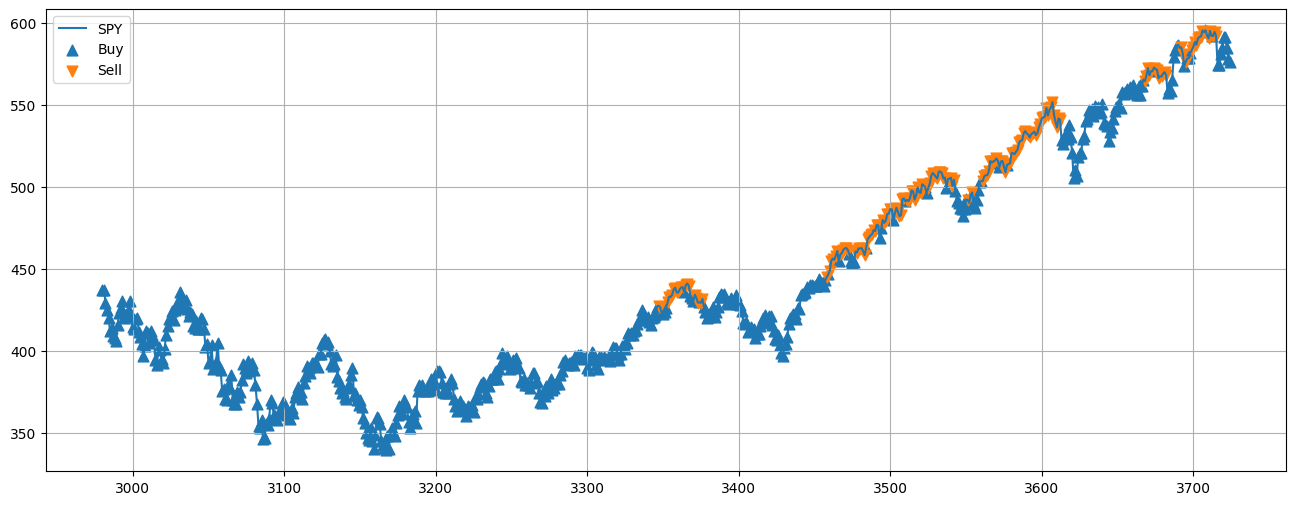

In [65]:
#buy/sell signals
buy = results[
    results["Signal"]==1
]

sell = results[
    results["Signal"]==0
]

plt.figure(figsize=(16,6))

plt.plot(
    results.index,
    results["Close"],
    label="SPY"
)

plt.scatter(
    buy.index,
    buy["Close"],
    marker="^",
    s=60,
    label="Buy"
)

plt.scatter(
    sell.index,
    sell["Close"],
    marker="v",
    s=60,
    label="Sell"
)

plt.legend()

plt.grid(True)

plt.show()

In [66]:
#final comparison
summary = pd.DataFrame({

    "Metric":[
        "Total Return",
        "Annual Return",
        "Volatility",
        "Sharpe Ratio",
        "Max Drawdown",
        "Number of Trades",
        "Win Rate"
    ],

    "ML Strategy":[
        strategy_return,
        annual_strategy,
        strategy_vol,
        strategy_sharpe,
        max_drawdown,
        num_trades,
        win_rate
    ],

    "Buy & Hold":[
        market_return,
        annual_market,
        market_vol,
        market_sharpe,
        "N/A",
        1,
        "N/A"
    ]
})

summary

,Metric,ML Strategy,Buy & Hold
0,Total Return,0.344850,0.318314
1,Annual Return,0.105413,0.097986
2,Volatility,0.167106,0.175348
3,Sharpe Ratio,0.630817,0.558812
4,Max Drawdown,-0.223859,N/A
5,Number of Trades,58.000000,1
6,Win Rate,0.523643,N/A


In [71]:
summary.to_csv("../results/DAY5/backtesting_summary.csv", index=False)

In [69]:
backtest = pd.DataFrame({
    "Strategy_Return": results["Strategy_Return"],
    "BuyHold_Return": results["Market_Return"]
})

backtest["Strategy_Cumulative"] = (1 + backtest["Strategy_Return"]).cumprod()
backtest["BuyHold_Cumulative"] = (1 + backtest["BuyHold_Return"]).cumprod()

backtest.to_csv("backtest_results.csv", index=True)

print("Backtest results saved successfully!")

Backtest results saved successfully!
